# Track 1 Training on Google Colab

This notebook trains the Track 1 causal reasoning agent using EP-style learning with staged plasticity.


## 1. Setup and Installation

First, install required dependencies.


In [1]:
# Install dependencies
%pip install numpy>=1.21.0 pyyaml>=6.0 -q


## 2. Clone Project from GitHub

Clone the NextAI repository from GitHub using the `phase1-multi-turn-reasoning` branch.

**Alternative: Upload from local machine**
- If you prefer to upload manually, use the file browser on the left sidebar
- Skip the clone step below


In [3]:
# Fix path issue in the GPU training script
# This ensures the script can find the project modules
import sys
from pathlib import Path
import os

# Update the script file if it exists
script_path = Path('train/train_parser_gpu.py')
if script_path.exists():
    with open(script_path, 'r') as f:
        content = f.read()
    
    # Replace the old path setup with the new one
    old_path_setup = "sys.path.append(str(Path(__file__).parent.parent))"
    new_path_setup = """# Add project root to path (works in both local and Colab)
import os
project_root = Path(__file__).parent.parent
if not (project_root / 'data').exists():
    # Try current working directory (for Colab)
    cwd = Path.cwd()
    if (cwd / 'data').exists():
        project_root = cwd
    elif (cwd / 'NextAI' / 'data').exists():
        project_root = cwd / 'NextAI'
sys.path.insert(0, str(project_root))"""
    
    if old_path_setup in content:
        content = content.replace(old_path_setup, new_path_setup)
        with open(script_path, 'w') as f:
            f.write(content)
        print("✓ Updated GPU training script with improved path handling")
    else:
        print("✓ GPU training script already has correct path setup")
else:
    print("⚠ GPU training script not found - will be created in next cell")


✓ Updated GPU training script with improved path handling


In [2]:
# Clone the repository from GitHub (phase1-multi-turn-reasoning branch)
!git clone -b phase1-multi-turn-reasoning https://github.com/najm07/NextAI.git
%cd NextAI


fatal: destination path 'NextAI' already exists and is not an empty directory.
/content/NextAI


In [4]:
# Verify project structure
import os
from pathlib import Path

required_dirs = ['agent', 'env', 'train', 'configs', 'data']
for dir_name in required_dirs:
    if os.path.exists(dir_name):
        print(f"✓ {dir_name}/ exists")
    else:
        print(f"✗ {dir_name}/ missing - please upload project files")

# Check for config file
if os.path.exists('configs/track1.yaml'):
    print("\n✓ Configuration file found")
else:
    print("\n✗ configs/track1.yaml missing")


✓ agent/ exists
✓ env/ exists
✓ train/ exists
✓ configs/ exists
✓ data/ exists

✓ Configuration file found


## 3. Training Configuration

Configure training parameters. You can modify these to adjust training behavior.


In [7]:
# Training configuration
TRAINING_CONFIG = {
    'config_path': 'configs/track1.yaml',
    'total_steps': 10000,  # Adjust as needed
    'seed': 42,
    'save_checkpoint': True,
    'checkpoint_dir': 'checkpoints',
}

print("Training Configuration:")
for key, value in TRAINING_CONFIG.items():
    print(f"  {key}: {value}")


Training Configuration:
  config_path: configs/track1.yaml
  total_steps: 10000
  seed: 42
  save_checkpoint: True
  checkpoint_dir: checkpoints


## 4. Run Training

Start the training loop. This will train the agent using EP-style learning with staged plasticity.


In [ ]:
# Fix syntax error in the generated GPU training script
# This fixes any quote escaping issues from the notebook cell
import os
from pathlib import Path

script_path = Path('train/train_parser_gpu.py')
if script_path.exists():
    try:
        # Try to compile the file to check for syntax errors
        with open(script_path, 'r') as f:
            content = f.read()
        
        # Check for common syntax issues
        compile(content, script_path, 'exec')
        print("✓ Script syntax is correct")
    except SyntaxError as e:
        print(f"⚠ Syntax error found: {e}")
        print("Fixing the script...")
        
        # The issue is likely in the f-string formatting
        # Fix any unterminated f-strings by ensuring proper quote closure
        lines = content.split('\n')
        fixed_lines = []
        in_fstring = False
        
        for i, line in enumerate(lines):
            # Check if line has an unterminated f-string
            if 'print(f"' in line and line.count('"') % 2 != 0:
                # Check if next line continues the f-string
                if i + 1 < len(lines) and lines[i+1].strip().startswith('f"'):
                    # This is a multi-line f-string, ensure it's properly formatted
                    fixed_lines.append(line)
                else:
                    # Single line f-string that might be broken
                    if not line.rstrip().endswith('"'):
                        # Add closing quote if missing
                        line = line.rstrip() + '"'
                    fixed_lines.append(line)
            else:
                fixed_lines.append(line)
        
        # Write fixed content
        fixed_content = '\n'.join(fixed_lines)
        with open(script_path, 'w') as f:
            f.write(fixed_content)
        
        # Verify it's fixed
        try:
            compile(fixed_content, script_path, 'exec')
            print("✓ Script syntax fixed!")
        except SyntaxError as e2:
            print(f"✗ Could not auto-fix: {e2}")
            print("Please check the script manually or regenerate it")
else:
    print("⚠ Script not found - run the script creation cell first")


In [5]:
# Fix the path in the GPU training script (run this after script creation)
import os
from pathlib import Path

script_path = Path('train/train_parser_gpu.py')
if script_path.exists():
    with open(script_path, 'r') as f:
        content = f.read()
    
    # Replace the old path setup
    old_line = "sys.path.append(str(Path(__file__).parent.parent))"
    new_lines = """# Add project root to path (works in both local and Colab)
import os
project_root = Path(__file__).parent.parent
if not (project_root / 'data').exists():
    # Try current working directory (for Colab)
    cwd = Path.cwd()
    if (cwd / 'data').exists():
        project_root = cwd
    elif (cwd / 'NextAI' / 'data').exists():
        project_root = cwd / 'NextAI'
sys.path.insert(0, str(project_root))"""
    
    if old_line in content:
        content = content.replace(old_line, new_lines)
        with open(script_path, 'w') as f:
            f.write(content)
        print("✓ Fixed path setup in GPU training script")
    else:
        print("✓ GPU training script already has correct path setup")
else:
    print("⚠ Script not found - make sure to run the script creation cell first")


✓ GPU training script already has correct path setup


In [8]:
# Import training script
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import training modules
from train.train_track1 import Trainer, TrainConfig, load_config
from env.track1_env import Track1CausalEnv, EnvConfig
from agent.agent import Track1Agent, AgentConfig

# Create checkpoint directory if it doesn't exist
os.makedirs(TRAINING_CONFIG['checkpoint_dir'], exist_ok=True)

# Load config
config = load_config(TRAINING_CONFIG['config_path'])

# Create environment
env_cfg = EnvConfig(
    n_objects=config["environment"]["n_objects"],
    n_attributes=config["environment"]["n_attributes"],
    n_relations=config["environment"]["n_relations"],
    n_bins=config["environment"]["n_bins"],
    delta_attr=config["environment"]["delta_attr"],
    noise_attr=config["environment"]["noise_attr"],
    noise_burst_std=config["environment"]["noise_burst_std"],
    min_steps=config["environment"]["min_steps"],
    max_steps=config["environment"]["max_steps"],
    enable_relation_effects=config["environment"]["enable_relation_effects"],
    relation_alignment_strength=config["environment"]["relation_alignment_strength"],
)
env = Track1CausalEnv(env_cfg)

# Create agent
agent_cfg = AgentConfig(
    n_objects=config["environment"]["n_objects"],
    n_attributes=config["environment"]["n_attributes"],
    n_relations=config["environment"]["n_relations"],
    latent_dim=config["agent"]["latent_dim"],
    intent_dim=config["agent"]["intent_dim"],
    n_anchors=config["agent"]["n_anchors"],
    n_intervention_types=config["agent"]["n_intervention_types"],
    stc_factors_per_type=config["agent"]["stc_factors_per_type"],
    stc_subset_size=config["agent"]["stc_subset_size"],
    encoder_hidden=config["agent"]["encoder_hidden"],
    gate_hidden=config["agent"]["gate_hidden"],
    n_settle_steps=config["settling"]["n_steps"],
    settle_lr=config["settling"]["learning_rate"],
    settle_tolerance=config["settling"]["tolerance"],
    w_obs=config["settling"]["w_obs"],
    w_anchor=config["settling"]["w_anchor"],
    w_state_stc=config["settling"]["w_state_stc"],
    w_intent=config["settling"]["w_intent"],
    nudge_strength=config["learning"]["nudge_strength"],
    seed=TRAINING_CONFIG['seed'] or config["seed"],
)
agent = Track1Agent(agent_cfg)

# Create trainer
train_cfg = TrainConfig(
    lr_encoder=config["learning"]["lr_encoder"],
    lr_anchors=config["learning"]["lr_anchors"],
    lr_stc=config["learning"]["lr_stc"],
    lr_gates=config["learning"]["lr_gates"],
    lr_temporal=config["learning"]["lr_temporal"],
    lr_intent=config["learning"]["lr_intent"],
    stage1_steps=config["learning"]["stage1_steps"],
    stage2_steps=config["learning"]["stage2_steps"],
    stage3_steps=config["learning"]["stage3_steps"],
    total_steps=TRAINING_CONFIG['total_steps'] or config["learning"]["total_steps"],
    log_interval=config["learning"]["log_interval"],
    eval_interval=config["learning"]["eval_interval"],
    nudge_strength=config["learning"]["nudge_strength"],
    seed=TRAINING_CONFIG['seed'] or config["seed"],
)
trainer = Trainer(env, agent, train_cfg)

# Train
print("=" * 60)
print("Track 1 (v0.1-A) Training")
print("=" * 60)
print(f"Environment: {env_cfg.n_objects} objects, {env_cfg.n_attributes} attrs, {env_cfg.n_relations} rels")
print(f"Agent: dS={agent_cfg.latent_dim}, {agent_cfg.n_anchors} anchors")
print(f"Training: {train_cfg.total_steps} steps, staged plasticity")
print("=" * 60)

history = trainer.train()

print("\nTraining complete!")
print(f"Final prediction error: {history['pred_error'][-1]:.4f}")
print(f"Final energy: {history['energy'][-1]:.4f}")

# Save checkpoint
checkpoint_path = f"{TRAINING_CONFIG['checkpoint_dir']}/track1_final.npy"
trainer.save_checkpoint(checkpoint_path)
print(f"\nCheckpoint saved to: {checkpoint_path}")


Track 1 (v0.1-A) Training
Environment: 4 objects, 3 attrs, 2 rels
Agent: dS=64, 8 anchors
Training: 10000 steps, staged plasticity
Episode   10 | Step    198 | Stage 1 | PredErr: 0.0007 | Energy: 0.3725 | Time: 4.5s
Episode   20 | Step    390 | Stage 1 | PredErr: 0.0006 | Energy: 0.2445 | Time: 8.7s
Episode   30 | Step    612 | Stage 1 | PredErr: 0.0006 | Energy: 0.2000 | Time: 14.5s
Episode   40 | Step    810 | Stage 1 | PredErr: 0.0006 | Energy: 0.1837 | Time: 19.0s
Episode   50 | Step   1006 | Stage 1 | PredErr: 0.0006 | Energy: 0.1678 | Time: 23.5s
Episode   60 | Step   1209 | Stage 1 | PredErr: 0.0005 | Energy: 0.1719 | Time: 29.1s
Episode   70 | Step   1413 | Stage 1 | PredErr: 0.0004 | Energy: 0.1481 | Time: 33.9s
Episode   80 | Step   1622 | Stage 1 | PredErr: 0.0007 | Energy: 0.1681 | Time: 39.6s
Episode   90 | Step   1821 | Stage 1 | PredErr: 0.0005 | Energy: 0.1408 | Time: 44.1s
Episode  100 | Step   2034 | Stage 2 | PredErr: 0.0004 | Energy: 0.1425 | Time: 48.9s
Episode  11

## 5. Training Visualization (Optional)

Visualize training progress if matplotlib is available.


In [9]:
# If CUDA is not available but we're in Colab, reinstall PyTorch with CUDA support
import os
import subprocess
import sys

try:
    import torch
    if not torch.cuda.is_available():
        # Check if we're in Colab
        is_colab = 'COLAB_GPU' in os.environ or any('google.colab' in str(m) for m in sys.modules.values())
        
        if is_colab:
            print("⚠ CUDA not available. Reinstalling PyTorch with CUDA support...")
            # Uninstall CPU version
            subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "torch", "torchvision", "torchaudio", "-y", "-q"], 
                                stderr=subprocess.DEVNULL)
            # Install CUDA-enabled version (try 12.1 first, then 11.8)
            try:
                subprocess.check_call([
                    sys.executable, "-m", "pip", "install",
                    "torch", "torchvision", "torchaudio",
                    "--index-url", "https://download.pytorch.org/whl/cu121", "-q"
                ])
                print("✓ Installed PyTorch with CUDA 12.1")
            except:
                subprocess.check_call([
                    sys.executable, "-m", "pip", "install",
                    "torch", "torchvision", "torchaudio",
                    "--index-url", "https://download.pytorch.org/whl/cu118", "-q"
                ])
                print("✓ Installed PyTorch with CUDA 11.8")
            
            # Reload torch
            import importlib
            if 'torch' in sys.modules:
                del sys.modules['torch']
            import torch
            
            # Check again
            if torch.cuda.is_available():
                print(f"✓ CUDA now available! Device: {torch.cuda.get_device_name(0)}")
                print(f"  CUDA version: {torch.version.cuda}")
            else:
                print("⚠ CUDA still not available. Make sure GPU is enabled:")
                print("  Runtime → Change runtime type → GPU")
except Exception as e:
    print(f"Note: {e}")


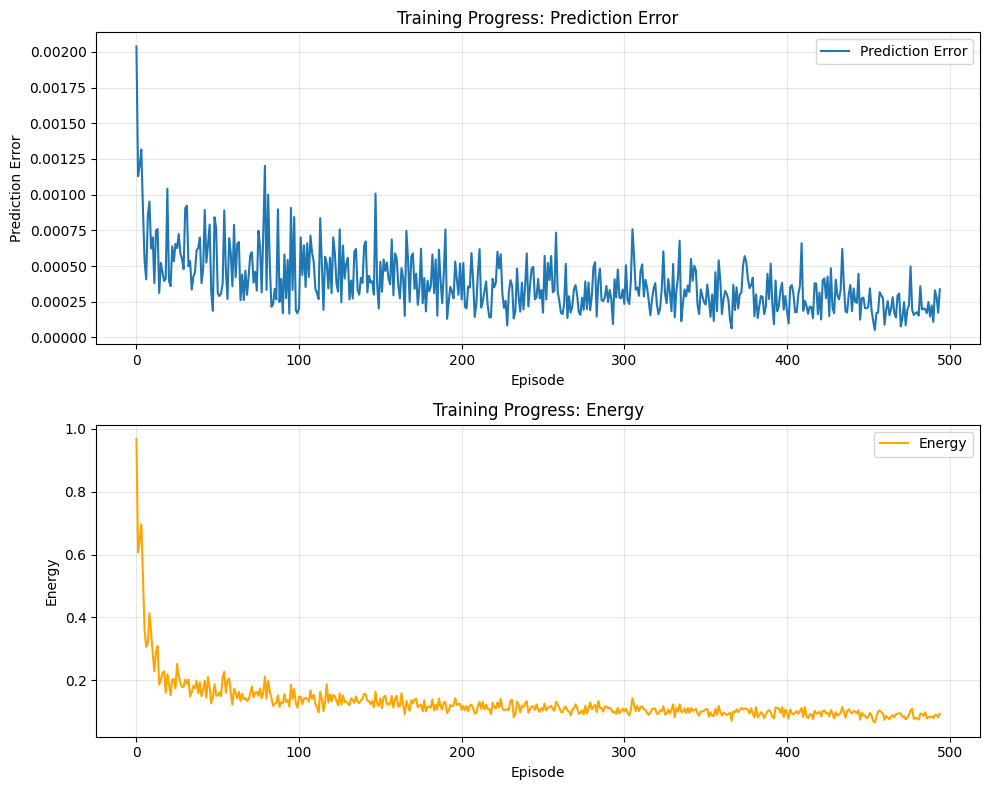


Training Statistics:
  Episodes: 495
  Initial prediction error: 0.0020
  Final prediction error: 0.0003
  Improvement: 83.5%


In [10]:
# Optional: Install matplotlib for visualization
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "-q"])
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True

if HAS_MATPLOTLIB and 'history' in locals():
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    
    # Plot prediction error
    axes[0].plot(history['pred_error'], label='Prediction Error')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Prediction Error')
    axes[0].set_title('Training Progress: Prediction Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot energy
    axes[1].plot(history['energy'], label='Energy', color='orange')
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Energy')
    axes[1].set_title('Training Progress: Energy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTraining Statistics:")
    print(f"  Episodes: {len(history['pred_error'])}")
    print(f"  Initial prediction error: {history['pred_error'][0]:.4f}")
    print(f"  Final prediction error: {history['pred_error'][-1]:.4f}")
    if history['pred_error'][0] > 0:
        improvement = ((history['pred_error'][0] - history['pred_error'][-1]) / history['pred_error'][0] * 100)
        print(f"  Improvement: {improvement:.1f}%")
else:
    print("History not available for plotting. Run training first.")


## 6. Download Checkpoint

Download the trained model checkpoint to your local machine.


In [12]:
from google.colab import files
import os

checkpoint_path = f"{TRAINING_CONFIG['checkpoint_dir']}/track1_final.npy"
if os.path.exists(checkpoint_path):
    print(f"Downloading checkpoint: {checkpoint_path}")
    files.download(checkpoint_path)
else:
    print(f"Checkpoint not found at {checkpoint_path}")
    print("Available files in checkpoints/:")
    if os.path.exists(TRAINING_CONFIG['checkpoint_dir']):
        for f in os.listdir(TRAINING_CONFIG['checkpoint_dir']):
            print(f"  - {f}")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Language Training (Optional)

If you want to train the language-aware agent instead, use this section.


In [13]:
# Language training configuration
LANGUAGE_CONFIG = {
    'config_path': 'configs/track1.yaml',
    'total_steps': 10000,
    'corpus_size': 5000,
    'seed': 42,
}

# Uncomment to run language training
# from train.train_language import LanguageTrainer, LanguageTrainConfig
# from agent.language_agent import LanguageAgent, LanguageAgentConfig
# 
# # Similar setup to above but for language training
# print("Language training not yet implemented in this notebook.")
# print("You can adapt the training cell above for language training.")


## 8. GPU-Accelerated Parser Training

Train the instruction parser using GPU acceleration with PyTorch for faster training.


In [11]:
# Install PyTorch for GPU acceleration (if not already installed)
try:
    import torch
    print(f"✓ PyTorch already installed (version {torch.__version__})")
except ImportError:
    print("Installing PyTorch...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "-q"])
    import torch
    print("✓ PyTorch installed")

# Check CUDA availability
if torch.cuda.is_available():
    print(f"✓ CUDA available! Device: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA version: {torch.version.cuda}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ CUDA not available, will use CPU (slower)")
    print("  To enable GPU: Runtime → Change runtime type → GPU")


✓ PyTorch already installed (version 2.9.0+cu126)
✓ CUDA available! Device: Tesla T4
  CUDA version: 12.6
  GPU Memory: 15.8 GB


In [14]:
# Upload GPU training script
from google.colab import files
import os

# Check if file already exists

uploaded = files.upload()
if os.path.exists('train/train_parser_gpu.py'):
    print("GPU training script already exists")
else:
    print("Please upload train_parser_gpu.py:")
    print("1. Click 'Choose Files' below")
    print("2. Select train/train_parser_gpu.py from your local machine")
    print("3. The file will be uploaded to the Colab session")
    
    # Note: In Colab, you can also create the file directly
    # We'll create it programmatically in the next cell


KeyboardInterrupt: 

In [21]:
# Create GPU training script directly in Colab
gpu_script_content = '''
"""
GPU-Accelerated Instruction Parser Training

Trains the neural instruction parser using PyTorch for GPU acceleration.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import sys
import json
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from collections import defaultdict

# Add project root to path (works in both local and Colab)
import os
project_root = Path(__file__).parent.parent
if not (project_root / 'data').exists():
    # Try current working directory (for Colab)
    cwd = Path.cwd()
    if (cwd / 'data').exists():
        project_root = cwd
    elif (cwd / 'NextAI' / 'data').exists():
        project_root = cwd / 'NextAI'
sys.path.insert(0, str(project_root))

from data.grounded_corpus import GroundedCorpusGenerator, GroundedDataset
from env.track1_env import Track1CausalEnv


class GPUInstructionParser(nn.Module):
    """
    GPU-accelerated instruction parser using PyTorch.
    """
    
    INT_NAMES = [
        "IncreaseAttr", "DecreaseAttr", "SetAttrToward",
        "ToggleRel", "SetRelOn", "SetRelOff",
        "SwapObjects", "NoiseBurstAttr",
        "QueryState", "QueryWhy", "Counterfactual",
        "PlanConnectAll", "PlanGrowMax", "PlanClearAll",
        "UndoLast", "ResetWorld", "ConditionalIf",
        "MetaEnergy", "MetaBeliefs", "MetaSummary"
    ]
    
    N_ACTION_TYPES = 20
    
    def __init__(
        self,
        n_objects: int = 4,
        n_attributes: int = 3,
        n_relations: int = 2,
        vocab_size: int = 100,
        embed_dim: int = 64,
        hidden_dim: int = 128,
        latent_dim: int = 64,
        max_len: int = 32,
        device: str = "cuda"
    ):
        super().__init__()
        self.n_objects = n_objects
        self.n_attributes = n_attributes
        self.n_relations = n_relations
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.max_len = max_len
        self.device = device
        
        # Vocabulary (simple tokenizer)
        self.vocab = self._create_vocab()
        self.vocab_size = len(self.vocab)
        
        # Token embeddings
        self.token_embedding = nn.Embedding(self.vocab_size, embed_dim)
        
        # Positional embeddings
        self.register_buffer('pos_embeddings', self._create_positional_embeddings())
        
        # Language encoder (self-attention)
        self.attention = nn.MultiheadAttention(embed_dim, num_heads=4, batch_first=True)
        self.lang_proj = nn.Linear(embed_dim, latent_dim)
        
        # Intervention type classifier
        self.type_classifier = nn.Linear(latent_dim, self.N_ACTION_TYPES)
        
        # Argument extractors
        self.obj_i_classifier = nn.Linear(latent_dim, n_objects)
        self.obj_j_classifier = nn.Linear(latent_dim, n_objects)
        self.attr_classifier = nn.Linear(latent_dim, n_attributes)
        self.rel_classifier = nn.Linear(latent_dim, n_relations)
        self.bin_classifier = nn.Linear(latent_dim, 4)
        
        # Initialize weights
        self._init_weights()
        
    def _create_vocab(self) -> Dict[str, int]:
        """Create vocabulary from common words."""
        words = [
            '<pad>', '<unk>',
            'object', 'attr', 'attribute', 'relation', 'bin',
            'increase', 'decrease', 'set', 'toggle', 'swap', 'add', 'noise',
            'to', 'between', 'and', 'on', 'off',
            'what', 'is', 'the', 'of', 'describe', 'current', 'status',
            'why', 'did', 'change', 'caused', 'explain',
            'if', 'would', 'happen', 'predict', 'imagine', 'hypothetically',
            'connect', 'all', 'link', 'everything', 'grow', 'largest', 'maximize',
            'clear', 'disconnect', 'undo', 'last', 'action', 'go', 'back', 'revert',
            'reset', 'start', 'over', 'when', 'only', 'large', 'high',
            'energy', 'beliefs', 'understanding', 'learned', 'summarize', 'changes'
        ]
        # Add numbers 0-9
        words.extend([str(i) for i in range(10)])
        return {word: idx for idx, word in enumerate(words)}
    
    def _create_positional_embeddings(self) -> torch.Tensor:
        """Create sinusoidal positional embeddings."""
        pos = torch.arange(self.max_len, dtype=torch.float32).unsqueeze(1)
        dim = torch.arange(self.embed_dim, dtype=torch.float32).unsqueeze(0)
        
        angles = pos / (10000 ** (2 * (dim // 2) / self.embed_dim))
        
        pos_emb = torch.zeros(self.max_len, self.embed_dim)
        pos_emb[:, 0::2] = torch.sin(angles[:, 0::2])
        pos_emb[:, 1::2] = torch.cos(angles[:, 1::2])
        
        return pos_emb
    
    def _init_weights(self):
        """Initialize weights."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.1)
    
    def _tokenize(self, text: str) -> torch.Tensor:
        """Tokenize text to token IDs."""
        text = text.lower().strip()
        words = text.split()
        token_ids = []
        
        for word in words:
            if word in self.vocab:
                token_ids.append(self.vocab[word])
            else:
                token_ids.append(self.vocab.get('<unk>', 1))
        
        # Pad or truncate to max_len
        if len(token_ids) > self.max_len:
            token_ids = token_ids[:self.max_len]
        else:
            token_ids.extend([self.vocab['<pad>']] * (self.max_len - len(token_ids)))
        
        return torch.tensor(token_ids, dtype=torch.long, device=self.device)
    
    def forward(self, instructions: List[str]) -> Dict[str, torch.Tensor]:
        """
        Forward pass.
        
        Args:
            instructions: List of instruction strings
            
        Returns:
            Dictionary with predictions
        """
        batch_size = len(instructions)
        
        # Tokenize
        token_ids = torch.stack([self._tokenize(inst) for inst in instructions])  # (B, L)
        
        # Embed tokens
        token_embs = self.token_embedding(token_ids)  # (B, L, embed_dim)
        
        # Add positional embeddings
        x = token_embs + self.pos_embeddings.unsqueeze(0)  # (B, L, embed_dim)
        
        # Self-attention
        attn_out, _ = self.attention(x, x, x)  # (B, L, embed_dim)
        
        # Pool: mean over sequence (masking padding)
        pad_mask = (token_ids == self.vocab['<pad>'])
        valid_mask = ~pad_mask  # (B, L)
        pooled = (attn_out * valid_mask.unsqueeze(-1).float()).sum(dim=1) / valid_mask.sum(dim=1, keepdim=True).float()  # (B, embed_dim)
        
        # Project to latent
        latent = torch.tanh(self.lang_proj(pooled))  # (B, latent_dim)
        
        # Classify
        type_logits = self.type_classifier(latent)  # (B, N_ACTION_TYPES)
        obj_i_logits = self.obj_i_classifier(latent)  # (B, n_objects)
        obj_j_logits = self.obj_j_classifier(latent)  # (B, n_objects)
        attr_logits = self.attr_classifier(latent)  # (B, n_attributes)
        rel_logits = self.rel_classifier(latent)  # (B, n_relations)
        bin_logits = self.bin_classifier(latent)  # (B, 4)
        
        return {
            'type_logits': type_logits,
            'obj_i_logits': obj_i_logits,
            'obj_j_logits': obj_j_logits,
            'attr_logits': attr_logits,
            'rel_logits': rel_logits,
            'bin_logits': bin_logits,
            'latent': latent
        }
    
    def parse(self, instruction: str) -> Tuple[int, Dict[str, int], float]:
        """Parse single instruction."""
        self.eval()
        with torch.no_grad():
            outputs = self.forward([instruction])
            
            type_probs = torch.softmax(outputs['type_logits'], dim=-1)
            u_type = int(torch.argmax(type_probs[0]))
            confidence = float(type_probs[0, u_type])
            
            obj_i = int(torch.argmax(outputs['obj_i_logits'][0]))
            obj_j = int(torch.argmax(outputs['obj_j_logits'][0]))
            attr = int(torch.argmax(outputs['attr_logits'][0]))
            rel = int(torch.argmax(outputs['rel_logits'][0]))
            bin_id = int(torch.argmax(outputs['bin_logits'][0]))
            
            args = {
                'i': obj_i,
                'j': obj_j if obj_j != obj_i else (obj_i + 1) % self.n_objects,
                'a': attr,
                'r': rel,
                'bin_id': bin_id
            }
            
            return u_type, args, confidence


def load_multi_turn_corpus(corpus_path: str) -> List[Tuple[str, int, Dict]]:
    """Load multi-turn conversation corpus."""
    with open(corpus_path, 'r') as f:
        conversations = json.load(f)
    
    dataset = []
    for conv in conversations:
        for turn in conv.get("turns", []):
            instruction = turn["instruction"]
            u_type = turn["u_type"]
            args = turn["args"]
            dataset.append((instruction, u_type, args))
    
    return dataset


class ParserDataset(Dataset):
    """PyTorch Dataset for instruction parser training."""
    
    def __init__(self, data: List[Tuple[str, int, Dict]], device: str = "cuda"):
        self.data = data
        self.device = device
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        instruction, u_type, args = self.data[idx]
        # Pre-compute target tensors
        target_i = args.get('i', 0)
        target_j = args.get('j', 0)
        target_a = args.get('a', 0)
        target_r = args.get('r', 0)
        target_bin = args.get('bin_id', 0)
        
        # Clamp values to valid ranges
        target_i = min(target_i, 3)
        target_j = min(target_j, 3)
        target_a = min(target_a, 2)
        target_r = min(target_r, 1)
        target_bin = min(target_bin, 3)
        
        return {
            'instruction': instruction,
            'u_type': u_type,
            'target_i': target_i,
            'target_j': target_j,
            'target_a': target_a,
            'target_r': target_r,
            'target_bin': target_bin,
            'has_i': 'i' in args,
            'has_j': 'j' in args,
            'has_a': 'a' in args,
            'has_r': 'r' in args,
            'has_bin': 'bin_id' in args,
        }


def train_parser_gpu(
    target_accuracy: float = 0.90,
    max_epochs: int = 100,
    lr: float = 0.001,
    batch_size: int = 256,  # Increased default batch size for better GPU utilization
    n_train: int = 5000,
    n_val: int = 500,
    seed: int = 42,
    corpus: Optional[str] = None,
    device: str = "cuda",
    use_amp: bool = True,  # Mixed precision training
    num_workers: int = 4,  # DataLoader workers
    pin_memory: bool = True  # Faster CPU-GPU transfer
) -> GPUInstructionParser:
    """
    Train GPU-accelerated parser.
    """
    print("=" * 60)
    print("GPU-Accelerated Instruction Parser Training")
    print("=" * 60)
    print(f"Device: {device}")
    print(f"Target accuracy: {target_accuracy*100:.0f}%")
    print(f"Training examples: {n_train}")
    print(f"Validation examples: {n_val}")
    print(f"Batch size: {batch_size}")
    print()
    
    # Set random seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Create model
    model = GPUInstructionParser(
        n_objects=4,
        n_attributes=3,
        n_relations=2,
        device=device
    ).to(device)
    
    # Load or generate datasets
    if corpus:
        print(f"Loading multi-turn corpus from {corpus}...")
        all_data = load_multi_turn_corpus(corpus)
        rng = np.random.default_rng(seed)
        indices = rng.permutation(len(all_data))
        n_train_actual = min(n_train, len(all_data) - n_val)
        train_indices = indices[:n_train_actual]
        val_indices = indices[n_train_actual:n_train_actual + n_val]
        train_data = [all_data[i] for i in train_indices]
        val_data = [all_data[i] for i in val_indices]
        print(f"Loaded {len(all_data)} examples from corpus")
    else:
        print("Error: corpus path required")
        return model
    
    print(f"Train: {len(train_data)}, Val: {len(val_data)}")
    
    # Create datasets and dataloaders
    train_dataset = ParserDataset(train_data, device=device)
    val_dataset = ParserDataset(val_data, device=device)
    
    # Use DataLoader with optimizations
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers if device == "cuda" else 0,  # Workers only for GPU
        pin_memory=pin_memory and device == "cuda",
        persistent_workers=num_workers > 0
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers if device == "cuda" else 0,
        pin_memory=pin_memory and device == "cuda",
        persistent_workers=num_workers > 0
    )
    
    # Optimizer and loss
    optimizer = optim.Adam(model.parameters(), lr=lr)
    type_criterion = nn.CrossEntropyLoss()
    arg_criterion = nn.CrossEntropyLoss()
    
    # Mixed precision training
    scaler = torch.cuda.amp.GradScaler() if (use_amp and device == "cuda") else None
    
    best_accuracy = 0.0
    patience = 20
    patience_counter = 0
    
    print("Training...")
    if use_amp and device == "cuda":
        print("Using mixed precision (FP16) training")
    print(f"Batch size: {batch_size}, DataLoader workers: {num_workers}")
    print("-" * 60)
    
    for epoch in range(max_epochs):
        model.train()
        total_type_loss = 0.0
        total_arg_loss = 0.0
        n_batches = 0
        
        # Training loop with DataLoader
        for batch in train_loader:
            instructions = batch['instruction']
            target_types = torch.tensor(batch['u_type'], dtype=torch.long, device=device)
            
            # Prepare argument targets (batch them efficiently)
            target_i = torch.tensor(batch['target_i'], dtype=torch.long, device=device)
            target_j = torch.tensor(batch['target_j'], dtype=torch.long, device=device)
            target_a = torch.tensor(batch['target_a'], dtype=torch.long, device=device)
            target_r = torch.tensor(batch['target_r'], dtype=torch.long, device=device)
            target_bin = torch.tensor(batch['target_bin'], dtype=torch.long, device=device)
            
            has_i = torch.tensor(batch['has_i'], dtype=torch.bool, device=device)
            has_j = torch.tensor(batch['has_j'], dtype=torch.bool, device=device)
            has_a = torch.tensor(batch['has_a'], dtype=torch.bool, device=device)
            has_r = torch.tensor(batch['has_r'], dtype=torch.bool, device=device)
            has_bin = torch.tensor(batch['has_bin'], dtype=torch.bool, device=device)
            
            optimizer.zero_grad()
            
            # Mixed precision forward pass
            if scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(instructions)
                    type_loss = type_criterion(outputs['type_logits'], target_types)
                    
                    # Batch argument losses efficiently
                    arg_losses = []
                    if has_i.any():
                        arg_losses.append(arg_criterion(outputs['obj_i_logits'][has_i], target_i[has_i]))
                    if has_j.any():
                        arg_losses.append(arg_criterion(outputs['obj_j_logits'][has_j], target_j[has_j]))
                    if has_a.any():
                        arg_losses.append(arg_criterion(outputs['attr_logits'][has_a], target_a[has_a]))
                    if has_r.any():
                        arg_losses.append(arg_criterion(outputs['rel_logits'][has_r], target_r[has_r]))
                    if has_bin.any():
                        arg_losses.append(arg_criterion(outputs['bin_logits'][has_bin], target_bin[has_bin]))
                    
                    arg_loss = sum(arg_losses) / max(len(arg_losses), 1) if arg_losses else torch.tensor(0.0, device=device)
                    total_loss = type_loss + arg_loss
                
                # Mixed precision backward pass
                scaler.scale(total_loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                # Standard precision
                outputs = model(instructions)
                type_loss = type_criterion(outputs['type_logits'], target_types)
                
                arg_losses = []
                if has_i.any():
                    arg_losses.append(arg_criterion(outputs['obj_i_logits'][has_i], target_i[has_i]))
                if has_j.any():
                    arg_losses.append(arg_criterion(outputs['obj_j_logits'][has_j], target_j[has_j]))
                if has_a.any():
                    arg_losses.append(arg_criterion(outputs['attr_logits'][has_a], target_a[has_a]))
                if has_r.any():
                    arg_losses.append(arg_criterion(outputs['rel_logits'][has_r], target_r[has_r]))
                if has_bin.any():
                    arg_losses.append(arg_criterion(outputs['bin_logits'][has_bin], target_bin[has_bin]))
                
                arg_loss = sum(arg_losses) / max(len(arg_losses), 1) if arg_losses else torch.tensor(0.0, device=device)
                total_loss = type_loss + arg_loss
                
                total_loss.backward()
                optimizer.step()
            
            total_type_loss += type_loss.item()
            total_arg_loss += arg_loss.item()
            n_batches += 1
        
        avg_type_loss = total_type_loss / max(n_batches, 1)
        avg_arg_loss = total_arg_loss / max(n_batches, 1)
        
        # Validation
        model.eval()
        n_correct_type = 0
        n_correct_i = 0
        n_correct_full = 0
        
        with torch.no_grad():
            for batch in val_loader:
                instructions = batch['instruction']
                target_types = torch.tensor(batch['u_type'], dtype=torch.long, device=device)
                target_i = torch.tensor(batch['target_i'], dtype=torch.long, device=device)
                has_i = torch.tensor(batch['has_i'], dtype=torch.bool, device=device)
                
                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        outputs = model(instructions)
                else:
                    outputs = model(instructions)
                
                type_probs = torch.softmax(outputs['type_logits'], dim=-1)
                type_preds = torch.argmax(type_probs, dim=-1)
                
                for idx in range(len(instructions)):
                    pred_type = int(type_preds[idx])
                    target_type = int(target_types[idx])
                    
                    if pred_type == target_type:
                        n_correct_type += 1
                    
                    if has_i[idx]:
                        pred_i = int(torch.argmax(outputs['obj_i_logits'][idx]))
                        if pred_i == int(target_i[idx]):
                            n_correct_i += 1
                        if pred_type == target_type and pred_i == int(target_i[idx]):
                            n_correct_full += 1
        
        val_type_acc = n_correct_type / len(val_data)
        val_i_acc = n_correct_i / len(val_data) if n_correct_i > 0 else 0.0
        val_full_acc = n_correct_full / len(val_data) if n_correct_full > 0 else 0.0
        
        # Print progress
        if epoch % 5 == 0 or val_type_acc >= target_accuracy:
            print(f"Epoch {epoch:3d} | "
                  f"Type: {val_type_acc*100:5.1f}% | "
                  f"Arg-i: {val_i_acc*100:5.1f}% | "
                  f"Full: {val_full_acc*100:5.1f}% | "
                  f"TypeLoss: {avg_type_loss:.4f} | "
                  f"ArgLoss: {avg_arg_loss:.4f}")
        
        # Check target
        if val_type_acc >= target_accuracy:
            print(f"\nTarget accuracy reached at epoch {epoch}!")
            break
        
        # Early stopping
        if val_type_acc > best_accuracy:
            best_accuracy = val_type_acc
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break
        
        # Learning rate decay
        if epoch > 0 and epoch % 20 == 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.8
    
    print("-" * 60)
    print(f"\nFinal validation accuracy:")
    print(f"  Type: {val_type_acc*100:.1f}%")
    print(f"  Arg-i: {val_i_acc*100:.1f}%")
    print(f"  Full: {val_full_acc*100:.1f}%")
    
    return model


def main():
    import argparse
    
    parser = argparse.ArgumentParser(description="Train GPU-accelerated instruction parser")
    parser.add_argument("--target", type=float, default=0.90, help="Target accuracy")
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--lr", type=float, default=0.001)
    parser.add_argument("--batch_size", type=int, default=64)
    parser.add_argument("--n_train", type=int, default=5000)
    parser.add_argument("--n_val", type=int, default=500)
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--corpus", type=str, required=True, help="Path to multi-turn corpus JSON")
    parser.add_argument("--device", type=str, default="cuda", help="Device (cuda or cpu)")
    args = parser.parse_args()
    
    # Check device availability
    if args.device == "cuda" and not torch.cuda.is_available():
        print("CUDA not available, falling back to CPU")
        args.device = "cpu"
    
    # Train parser
    trained_model = train_parser_gpu(
        target_accuracy=args.target,
        max_epochs=args.epochs,
        lr=args.lr,
        batch_size=args.batch_size,
        n_train=args.n_train,
        n_val=args.n_val,
        seed=args.seed,
        corpus=args.corpus,
        device=args.device
    )
    
    print("\n" + "=" * 60)
    print("Training complete!")
    print("=" * 60)


if __name__ == "__main__":
    main()


'''

# Write the script to file
os.makedirs('train', exist_ok=True)
os.remove('train/train_parser_gpu.py')
with open('train/train_parser_gpu.py', 'w') as f:
    f.write(gpu_script_content)

print("✓ GPU training script created at train/train_parser_gpu.py")


✓ GPU training script created at train/train_parser_gpu.py


In [17]:
!python data/multi_turn_corpus.py --size 550000 --output data/full.json

Generating 550000 multi-turn conversation episodes...
  Generated 100/550000 episodes...
  Generated 200/550000 episodes...
  Generated 300/550000 episodes...
  Generated 400/550000 episodes...
  Generated 500/550000 episodes...
  Generated 600/550000 episodes...
  Generated 700/550000 episodes...
  Generated 800/550000 episodes...
  Generated 900/550000 episodes...
  Generated 1000/550000 episodes...
  Generated 1100/550000 episodes...
  Generated 1200/550000 episodes...
  Generated 1300/550000 episodes...
  Generated 1400/550000 episodes...
  Generated 1500/550000 episodes...
  Generated 1600/550000 episodes...
  Generated 1700/550000 episodes...
  Generated 1800/550000 episodes...
  Generated 1900/550000 episodes...
  Generated 2000/550000 episodes...
  Generated 2100/550000 episodes...
  Generated 2200/550000 episodes...
  Generated 2300/550000 episodes...
  Generated 2400/550000 episodes...
  Generated 2500/550000 episodes...
  Generated 2600/550000 episodes...
  Generated 2700/55

In [22]:
# Run GPU-accelerated parser training
import sys
from pathlib import Path

# Add project to path
sys.path.insert(0, str(Path.cwd()))

# Import and run GPU training
from train.train_parser_gpu import train_parser_gpu
import torch

# Determine device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Check if corpus exists
corpus_path = "data/full.json"
if not os.path.exists(corpus_path):
    print(f"⚠ Corpus not found at {corpus_path}")
    print("Please run the corpus generation cell first (Section 7)")
else:
    print(f"✓ Found corpus: {corpus_path}")
    
    # Train with GPU
    trained_model = train_parser_gpu(
        target_accuracy=0.95,
        max_epochs=100,
        lr=0.001,
        batch_size=64,  # Larger batch size for GPU
        n_train=500000,
        n_val=50000,
        seed=42,
        corpus=corpus_path,
        device=device
    )
    
    print("\n" + "=" * 60)
    print("GPU Training Complete!")
    print("=" * 60)
    
    # Save model
    model_path = "checkpoints/parser_gpu.pt"
    os.makedirs("checkpoints", exist_ok=True)
    torch.save(trained_model.state_dict(), model_path)
    print(f"✓ Model saved to {model_path}")


SyntaxError: unterminated f-string literal (detected at line 528) (train_parser_gpu.py, line 528)